# Test Sheet: Predicting Employee Salaries Based on Experience and Education Using Linear Regression

In this assignment, we are building and evaluating a Linear Regression Model to predict employee salaries based on their years of experience and education level. 

**Kalpana Biswa**

## Generating Data

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [2]:
np.random.seed(42)
n = 100

experience = np.random.randint(1, 21, size=n)
education_level = np.random.choice([1, 2, 3], size=n)
salary = 80000 + (experience * 2000) + (education_level * 10000) + np.random.normal(0, 5000, size=n)

df = pd.DataFrame({
    'experience': experience,
    'education_level': education_level,
    'salary': salary
})
df

,experience,education_level,salary
0,7,3,121126.453962
1,20,2,137892.508898
2,15,3,141699.104821
3,11,3,131963.099250
4,8,1,109836.484194
...,...,...,...
95,12,2,125286.037455
96,2,3,114119.659072
97,1,1,96359.569944
98,16,1,129186.781642


## Data Preprocessing 

In [3]:


X_train, X_test, y_train, y_test = train_test_split(df[['experience', 'education_level']], df['salary'], test_size=0.2, random_state=42)

train_test_split_data = {
    'Training Features': X_train,
    'Test Features': X_test,
    'Training Target': y_train,
    'Test Target': y_test
}

train_test_data = pd.concat([X_train, y_train], axis=1)
train_test_data.head()



,experience,education_level,salary
55,4,3,122702.677925
88,5,1,104362.235788
26,20,3,148058.678005
42,12,2,125131.441347
69,18,1,130885.900004


## Train the Linear Regression Model

In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model_coefficients = model.coef_
model_intercept = model.intercept_

model_coefficients, model_intercept


(array([1867.81943752, 9960.44334968]), 82382.17942692092)

## Evaluate the Model

In [5]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
mse, r_squared


(27136006.68726777, 0.8674783904180692)

## Make Predictions

In [6]:
new_employee = [[7, 2]]
predicted_salary = model.predict(new_employee)
predicted_salary


/Users/kalpana/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([115377.80218891])

## Visualizations

Text(0.5, 1.0, 'Experience vs. Salary')

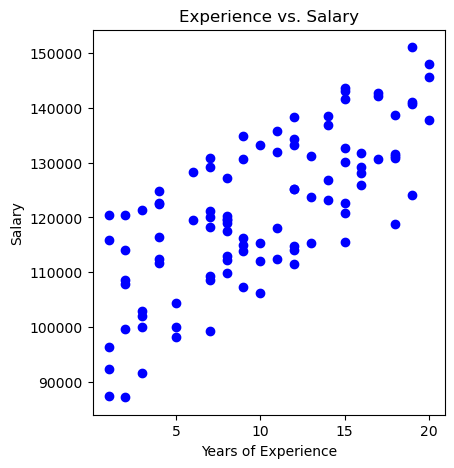

In [7]:

# Scatter plot for experience vs. salary
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(df['experience'], df['salary'], color='blue', label='Actual Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs. Salary')

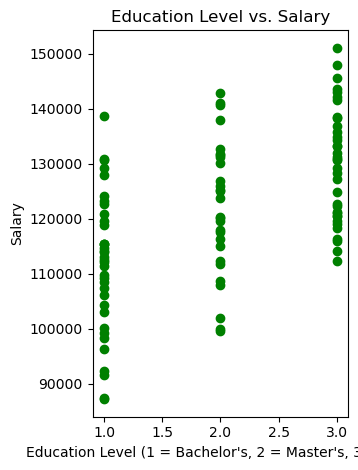

In [8]:
# Scatter plot for education_level vs. salary
plt.subplot(1, 2, 2)
plt.scatter(df['education_level'], df['salary'], color='green', label='Actual Salary')
plt.xlabel('Education Level (1 = Bachelor\'s, 2 = Master\'s, 3 = PhD)')
plt.ylabel('Salary')
plt.title('Education Level vs. Salary')

plt.tight_layout()
plt.show()



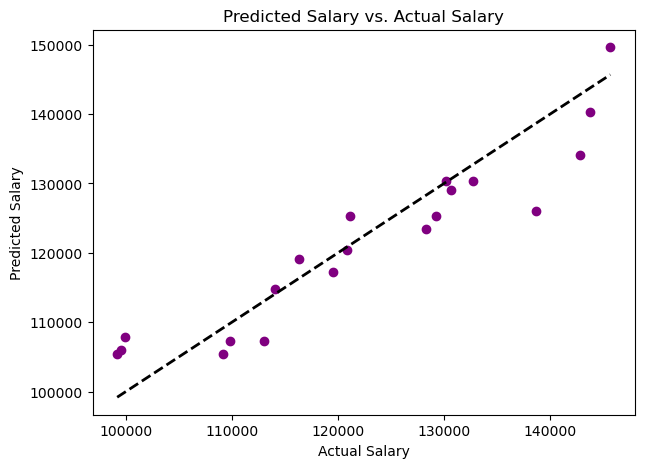

In [9]:
# Visualize model predictions vs. actual salary
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Predicted Salary vs. Actual Salary')
plt.show()